# Phase 2: Multi-Model Evaluation & Cross-Member Comparison
**Coursework:** IT2011 Machine Learning Project  
**Author:** Group Evaluation Pipeline (All Members)  
**Scope:** Phase 2 Model Benchmark & Statistical Significance Testing  

This notebook performs the comprehensive, standardized evaluation and comparison of the models trained across all group members for Phase 2. It reads the serialized results and predictions generated via `src.evaluation.save_model_results()` and **trains no estimators**.

Before aggregating metrics, this notebook verifies strict comparability across all delivered model artifacts (identical split fingerprints, identical 5-fold partitions, unique review identifiers, and exact confusion matrix reconstruction). All visual and tabular outputs are saved to `results/phase2/comparison/`.

### 1. Environment Setup & Configuration
Configure project paths, load evaluation utilities, and define the expected Phase 2 modeling roster across group members.

In [1]:
import os
import sys
import json
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure repository root is in sys.path
repo_root = None
if "REPO_ROOT" in os.environ:
    repo_root = Path(os.environ["REPO_ROOT"]).resolve()
else:
    current_dir = Path.cwd().resolve()
    for candidate in [current_dir] + list(current_dir.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            repo_root = candidate
            break
    if repo_root is None:
        repo_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data_prep import find_repo_root
from src.evaluation import (
    load_model_results,
    validate_results,
    confusion_matrix,
    confusion_matrix_normalized,
    movie_confusion_tensor,
    make_bootstrap_indices,
    bootstrap_macro_f1,
    paired_bootstrap_difference,
    percentile_ci,
)

REPO_ROOT = find_repo_root()

# Helper to format paths relative to REPO_ROOT without exposing machine-specific absolute paths
def rel(p):
    try:
        return str(Path(p).resolve().relative_to(REPO_ROOT.resolve()))
    except ValueError:
        return Path(p).name

# Allow overriding results directory via environment variable (used for testing)
RESULTS_DIR = Path(os.environ.get("PHASE2_RESULTS_DIR", REPO_ROOT / "results" / "phase2"))
COMPARISON_DIR = RESULTS_DIR / "comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

# Roles are authoritative here; model-authored JSON cannot promote a baseline.
EXPECTED_MODELS = {
    "naive_bayes": {"label": "Multinomial Naive Bayes", "member_id": "IT25102549", "role": "primary"},
    "logistic_regression": {"label": "Logistic Regression", "member_id": "IT25102550", "role": "primary"},
    "linear_svc": {"label": "Linear Support Vector Machine", "member_id": "IT25102631", "role": "primary"},
    "random_forest": {"label": "Random Forest Classifier", "member_id": "IT25102877", "role": "primary"},
    "hist_gradient_boosting": {"label": "Gradient Boosting", "member_id": "IT25103066", "role": "primary"},
    "mlp": {"label": "Multi-Layer Perceptron (MLP)", "member_id": "IT25103132", "role": "primary"},
    "decision_tree": {
        "label": "Decision Tree",
        "member_id": "IT25102877",
        "role": "baseline",
        "note": "additional baseline of Member 4's Random Forest",
    },
}
PRIMARY_MODELS_EXPECTED = sum(spec["role"] == "primary" for spec in EXPECTED_MODELS.values())

print(f"Repository Root        : {REPO_ROOT.name}")
print(f"Results Directory      : {rel(RESULTS_DIR)}")
print(f"Comparison Output Dir  : {rel(COMPARISON_DIR)}")
print(f"Expected Model Roster  : {PRIMARY_MODELS_EXPECTED} primaries + {len(EXPECTED_MODELS) - PRIMARY_MODELS_EXPECTED} baseline")

Repository Root        : AI:ML Project
Results Directory      : results/phase2
Comparison Output Dir  : results/phase2/comparison
Expected Model Roster  : 6 primaries + 1 baseline


### 2. Discover & Load Delivered Model Results
Scan `RESULTS_DIR` for all `*_results.json` files, validate schemas via `validate_results()`, and report delivery status across the expected model roster.

In [2]:
# Discover all results JSON files in RESULTS_DIR
discovered_files = sorted(glob.glob(str(RESULTS_DIR / "*_results.json")))
delivered_data = {}
unexpected_files = []

for filepath in discovered_files:
    p = Path(filepath)
    try:
        data = load_model_results(p)
        model_key = data.get("model_key")
        delivered_data[model_key] = {
            "data": data,
            "filepath": p,
        }
        if model_key not in EXPECTED_MODELS:
            unexpected_files.append(model_key)
    except Exception as e:
        print(f"Error loading {p.name}: {e}")

# Build delivery status table
status_records = []
for model_key, spec in EXPECTED_MODELS.items():
    is_delivered = model_key in delivered_data
    status_records.append({
        "Model Key": model_key,
        "Algorithm / Model": spec["label"],
        "Member ID": spec["member_id"],
        "Role": spec["role"],
        "Status": "delivered" if is_delivered else "not delivered yet",
    })

status_df = pd.DataFrame(status_records)
print("=== Phase 2 Model Delivery Status ===")
print(status_df.to_string(index=False))
primary_models_delivered = sum(
    key in delivered_data and spec["role"] == "primary"
    for key, spec in EXPECTED_MODELS.items()
)
print(f"\nPrimary models delivered: {primary_models_delivered} of {PRIMARY_MODELS_EXPECTED}")

if unexpected_files:
    print(f"\nNotice: Discovered {len(unexpected_files)} additional model file(s) not in expected roster: {unexpected_files}")

=== Phase 2 Model Delivery Status ===
             Model Key             Algorithm / Model  Member ID     Role            Status
           naive_bayes       Multinomial Naive Bayes IT25102549  primary not delivered yet
   logistic_regression           Logistic Regression IT25102550  primary not delivered yet
            linear_svc Linear Support Vector Machine IT25102631  primary not delivered yet
         random_forest      Random Forest Classifier IT25102877  primary         delivered
hist_gradient_boosting             Gradient Boosting IT25103066  primary not delivered yet
                   mlp  Multi-Layer Perceptron (MLP) IT25103132  primary not delivered yet
         decision_tree                 Decision Tree IT25102877 baseline         delivered

Primary models delivered: 1 of 6


### 3. Comparability & Integrity Verification
Enforce strict experimental comparability checks across all delivered models before synthesizing metrics:
1. **Schema & Label Invariants:** Valid schema version and identical label ordering.
2. **Split Fingerprint:** Identical train/test row counts, test movie hash (`test_movies_sha256`), and test review hash (`test_review_ids_sha256`).
3. **Cross-Validation Invariants:** Identical 5-fold group partitions without leakage.
4. **Prediction Alignment:** Test predictions CSV must exist, `review_id` must be strictly unique, its exact sequence and ground-truth `y_true` must match the reference model, and the recomputed confusion matrix must match `test['confusion_matrix']`.
5. **Baselines:** Baseline benchmark scores must be identical across runs.

In [3]:
# Establish reference model for comparability checks (first delivered model)
split_keys = ["n_train", "n_test", "train_movies_sha256", "test_movies_sha256", "train_review_ids_sha256", "test_review_ids_sha256"]

ref_key = None
ref_data = None
ref_preds = None

# Identify reference model
for k, item in delivered_data.items():
    csv_path = RESULTS_DIR / f"{k}_test_predictions.csv"
    if csv_path.exists():
        ref_key = k
        ref_data = item["data"]
        ref_preds = pd.read_csv(csv_path)
        break

if ref_key is None:
    raise RuntimeError("No delivered model has an accompanying test predictions CSV.")

print(f"Reference Model for Comparability Checks: '{ref_key}'")

check_results = []
passed_models = {}
excluded_models = {}

for k, item in delivered_data.items():
    d = item["data"]
    reasons = []
    
    # 1. Schema version
    if d.get("schema_version") != ref_data.get("schema_version"):
        reasons.append(f"Schema version mismatch: {d.get('schema_version')} vs {ref_data.get('schema_version')}")
        
    # 2. Labels order
    if list(d.get("labels", [])) != list(ref_data.get("labels", [])):
        reasons.append("Labels order mismatch")
        
    # 3. Split fingerprint
    for sk in split_keys:
        val = d.get("split", {}).get(sk)
        ref_val = ref_data.get("split", {}).get(sk)
        if val != ref_val:
            reasons.append(f"Split fingerprint mismatch: {sk}")
            
    # 4. CV fingerprints
    if d.get("cv_fingerprints") != ref_data.get("cv_fingerprints"):
        reasons.append("CV fold fingerprints mismatch")
        
    # 5. Predictions CSV and alignment
    csv_path = RESULTS_DIR / f"{k}_test_predictions.csv"
    if not csv_path.exists():
        reasons.append("Missing test predictions CSV")
    else:
        p_df = pd.read_csv(csv_path)
        if p_df["review_id"].nunique() != len(p_df):
            reasons.append("Non-unique review_id in predictions")
        if list(p_df["review_id"]) != list(ref_preds["review_id"]):
            reasons.append("Predictions review_id sequence mismatch with reference")
        if list(p_df["y_true"]) != list(ref_preds["y_true"]):
            reasons.append("Predictions y_true sequence mismatch with reference")
        cm_recomp = confusion_matrix(p_df["y_true"], p_df["y_pred"], labels=d["labels"]).tolist()
        if cm_recomp != d["test"]["confusion_matrix"]:
            reasons.append("Recomputed confusion matrix does not match JSON confusion_matrix")
            
    # 6. Baselines
    if d.get("baselines") != ref_data.get("baselines"):
        reasons.append("Baseline benchmarks mismatch")
        
    # Check library versions (reported, does not fail)
    version_diffs = []
    for pkg, ver in d.get("created_with", {}).items():
        ref_ver = ref_data.get("created_with", {}).get(pkg)
        if ref_ver and ver != ref_ver:
            version_diffs.append(f"{pkg}:{ver} vs {ref_ver}")
            
    status = "PASS" if not reasons else "FAIL"
    reason_str = "; ".join(reasons) if reasons else "All comparability checks passed"
    
    check_results.append({
        "Model Key": k,
        "Status": status,
        "Issues / Failure Reason": reason_str,
        "Library Version Differences": ", ".join(version_diffs) if version_diffs else "None (Exact Match)",
    })
    
    if status == "PASS":
        passed_models[k] = {
            "data": d,
            "preds": p_df,
        }
    else:
        excluded_models[k] = reason_str

comparability_df = pd.DataFrame(check_results)
print("\n=== Comparability Verification Summary ===")
print(comparability_df[["Model Key", "Status", "Issues / Failure Reason"]].to_string(index=False))

print(f"\n✔ Passed Models ({len(passed_models)}): {list(passed_models.keys())}")
if excluded_models:
    print(f"⚠ Excluded Models ({len(excluded_models)}): {excluded_models}")

Reference Model for Comparability Checks: 'decision_tree'

=== Comparability Verification Summary ===
    Model Key Status         Issues / Failure Reason
decision_tree   PASS All comparability checks passed
random_forest   PASS All comparability checks passed

✔ Passed Models (2): ['decision_tree', 'random_forest']


### 4. Role-Aware Model Comparison Tables
Rank only the six members' verified primary models by held-out test Macro-F1. Additional model baselines are reported separately and cannot become the group's best model. Majority, stratified-random, and uniform-random rows remain explicit references.

In [4]:
# Compute test macro-F1 95% bootstrap confidence intervals for each passed model
n_movies = ref_preds["movie_name"].nunique()
shared_boot_idx = make_bootstrap_indices(n_movies=n_movies, n_boot=2000, seed=42)

boot_cis = {}
movie_tensors = {}

for k, pitem in passed_models.items():
    _, tensor = movie_confusion_tensor(pitem["preds"])
    movie_tensors[k] = tensor
    draws = bootstrap_macro_f1(tensor, shared_boot_idx)
    boot_cis[k] = percentile_ci(draws, level=0.95)

primary_models = {k: v for k, v in passed_models.items() if EXPECTED_MODELS[k]["role"] == "primary"}
baseline_models = {k: v for k, v in passed_models.items() if EXPECTED_MODELS[k]["role"] == "baseline"}
if not primary_models:
    raise RuntimeError("No comparable primary model is available; a group best model cannot be selected.")

table_rows = []
for k, pitem in passed_models.items():
    d = pitem["data"]
    meta = d["meta"]
    tuning = meta["tuning"]
    scoring_val = tuning.get("scoring", [])
    scoring_str = ", ".join(scoring_val) if isinstance(scoring_val, list) else str(scoring_val)
    
    cv = d["cv"]
    test = d["test"]
    ci = boot_cis[k]
    
    table_rows.append({
        "Model": meta.get("model_label", k),
        "Role": EXPECTED_MODELS[k]["role"],
        "Member ID": meta.get("member_id", "-"),
        "Algorithm": meta.get("algorithm", "-"),
        "Preprocessing": meta.get("preprocessing", "-"),
        "Tuning Budget": f"{tuning.get('method', '-')} ({tuning.get('n_configs', '-')} configs x {tuning.get('n_folds', '-')} folds, {scoring_str})",
        "CV Macro-F1 (Mean ± Std)": f"{cv['macro_f1']['mean']:.4f} ± {cv['macro_f1']['std']:.4f}",
        "CV Accuracy": f"{cv['accuracy']['mean']:.4f}",
        "Test Accuracy": f"{test['accuracy']:.4f}",
        "Test Macro-F1 (95% CI)": f"{test['macro_f1']:.4f} [{ci[0]:.4f}, {ci[1]:.4f}]",
        "Test Weighted-F1": f"{test['weighted_f1']:.4f}",
        "_raw_test_macro_f1": test["macro_f1"],
    })

# Rank primaries only; additional baselines remain unranked.
model_rows_df = pd.DataFrame(table_rows)
primary_df = (model_rows_df[model_rows_df["Role"] == "primary"]
              .sort_values(by="_raw_test_macro_f1", ascending=False)
              .drop(columns=["_raw_test_macro_f1"]))
additional_baselines_df = (model_rows_df[model_rows_df["Role"] == "baseline"]
                           .sort_values(by="_raw_test_macro_f1", ascending=False)
                           .drop(columns=["_raw_test_macro_f1"]))

# Append benchmark baseline reference rows
base = ref_data["baselines"]
baseline_rows = [
    {
        "Model": "Majority Class Predictor",
        "Role": "reference",
        "Member ID": "-",
        "Algorithm": "DummyClassifier (most_frequent)",
        "Preprocessing": "-",
        "Tuning Budget": "-",
        "CV Macro-F1 (Mean ± Std)": "-",
        "CV Accuracy": "-",
        "Test Accuracy": f"{base['majority']['accuracy']:.4f}",
        "Test Macro-F1 (95% CI)": f"{base['majority']['macro_f1']:.4f}",
        "Test Weighted-F1": f"{base['majority']['weighted_f1']:.4f}",
    },
    {
        "Model": "Stratified Random Baseline",
        "Role": "reference",
        "Member ID": "-",
        "Algorithm": "DummyClassifier (stratified, 200 seeds)",
        "Preprocessing": "-",
        "Tuning Budget": "-",
        "CV Macro-F1 (Mean ± Std)": "-",
        "CV Accuracy": "-",
        "Test Accuracy": f"{base['stratified_random']['accuracy_mean']:.4f} ± {base['stratified_random']['accuracy_std']:.4f}",
        "Test Macro-F1 (95% CI)": f"{base['stratified_random']['macro_f1_mean']:.4f} ± {base['stratified_random']['macro_f1_std']:.4f}",
        "Test Weighted-F1": "-",
    },
    {
        "Model": "Uniform Random Baseline",
        "Role": "reference",
        "Member ID": "-",
        "Algorithm": "DummyClassifier (uniform, 200 seeds)",
        "Preprocessing": "-",
        "Tuning Budget": "-",
        "CV Macro-F1 (Mean ± Std)": "-",
        "CV Accuracy": "-",
        "Test Accuracy": f"{base['uniform_random']['accuracy_mean']:.4f} ± {base['uniform_random']['accuracy_std']:.4f}",
        "Test Macro-F1 (95% CI)": f"{base['uniform_random']['macro_f1_mean']:.4f} ± {base['uniform_random']['macro_f1_std']:.4f}",
        "Test Weighted-F1": "-",
    },
]

baseline_and_reference_df = pd.concat([additional_baselines_df, pd.DataFrame(baseline_rows)], ignore_index=True)
full_comparison_df = pd.concat([primary_df, baseline_and_reference_df], ignore_index=True)

# Export comparison table to CSV and Markdown
csv_out = COMPARISON_DIR / "model_comparison_table.csv"
md_out = COMPARISON_DIR / "model_comparison_table.md"

full_comparison_df.to_csv(csv_out, index=False)

def _df_to_markdown(df):
    headers = list(df.columns)
    rows = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for _, r in df.iterrows():
        rows.append("| " + " | ".join(str(val) for val in r) + " |")
    return "\n".join(rows)

with open(md_out, "w", encoding="utf-8") as f:
    f.write(_df_to_markdown(full_comparison_df))

print("=== Primary Model Ranking (Test Macro-F1) ===")
print(primary_df.to_string(index=False))
print("\n=== Additional baselines (not ranked) ===")
print(baseline_and_reference_df.to_string(index=False))
print(f"\n✔ Table saved to: {rel(csv_out)} and {rel(md_out)}")

=== Primary Model Ranking (Test Macro-F1) ===
        Model    Role  Member ID              Algorithm                                                      Preprocessing                                                              Tuning Budget CV Macro-F1 (Mean ± Std) CV Accuracy Test Accuracy  Test Macro-F1 (95% CI) Test Weighted-F1
Random Forest primary IT25102877 RandomForestClassifier TF-IDF (2500) + Genre Binarizer (20) + Word Count (1) + Rating (1) RandomizedSearchCV (15 configs x 5 folds, macro_f1, accuracy, weighted_f1)          0.1708 ± 0.0138      0.2594        0.2729 0.1942 [0.1543, 0.2310]           0.2707

=== Additional baselines (not ranked) ===
                     Model      Role  Member ID                               Algorithm                                                      Preprocessing                                                        Tuning Budget CV Macro-F1 (Mean ± Std) CV Accuracy   Test Accuracy  Test Macro-F1 (95% CI) Test Weighted-F1
             

### 5. Role-Aware Statistical Significance Testing (Movie Bootstrap)
Select the best model and compute primary-model ties using primary submissions only. Additional baselines are compared against the best primary in a separate table and can never become the group winner. Reviews from the same movie share stylistic, thematic, and directorial characteristics, so bootstrap resampling is performed at the **movie cluster level** ($B=2,000$ cluster bootstrap draws with seed 42).

> **Important Methodological Note:** The cluster bootstrap isolates test-set sampling variation across movies. It does not measure variability originating from randomized training procedures (e.g., neural initialization) or cross-environment library differences.

In [5]:
# The group winner is selected from primary models only.
best_key = max(primary_models, key=lambda k: primary_models[k]["data"]["test"]["macro_f1"])
best_d = primary_models[best_key]["data"]
best_label = best_d["meta"].get("model_label", best_key)
best_score = best_d["test"]["macro_f1"]
best_tensor = movie_tensors[best_key]

primary_diff_records = []
tied_primary_models = []
for k, pitem in primary_models.items():
    if k == best_key:
        continue
    label = pitem["data"]["meta"].get("model_label", k)
    diff_draws = paired_bootstrap_difference(best_tensor, movie_tensors[k], shared_boot_idx)
    ci_diff = percentile_ci(diff_draws, level=0.95)
    mean_diff = float(np.mean(diff_draws))
    is_tied = ci_diff[0] <= 0 <= ci_diff[1]
    if is_tied:
        tied_primary_models.append(label)
    primary_diff_records.append({
        "Comparison": f"{best_label} vs. {label}",
        "Score Difference": f"{mean_diff:+.4f}",
        "95% CI of Difference": f"[{ci_diff[0]:.4f}, {ci_diff[1]:.4f}]",
        "Statistically Tied with Best?": "Yes (CI includes 0)" if is_tied else "No (Significant Difference)",
    })

primary_diff_df = pd.DataFrame(primary_diff_records)
if len(primary_models) < 2:
    print(f"Primary pairwise bootstrap skipped: only {len(primary_models)} comparable primary model delivered.")
else:
    print(f"=== Primary Pairwise Differences Against Best Primary ({best_label}) ===")
    print(primary_diff_df.to_string(index=False))

tie_names = ', '.join(tied_primary_models) if tied_primary_models else 'none'
tie_sentence = (
    f"Best primary model: {best_label} (Macro-F1: {best_score:.4f}). "
    f"Primary models statistically tied with the best: {len(tied_primary_models)} ({tie_names})."
)
print(f"\n{tie_sentence}")

baseline_diff_records = []
for k, pitem in baseline_models.items():
    label = pitem["data"]["meta"].get("model_label", k)
    diff_draws = paired_bootstrap_difference(best_tensor, movie_tensors[k], shared_boot_idx)
    ci_diff = percentile_ci(diff_draws, level=0.95)
    mean_diff = float(np.mean(diff_draws))
    baseline_diff_records.append({
        "Comparison": f"{k} vs best primary ({best_key})",
        "Baseline Label": label,
        "Score Difference (best - baseline)": f"{mean_diff:+.4f}",
        "95% CI of Difference": f"[{ci_diff[0]:.4f}, {ci_diff[1]:.4f}]",
        "Statistically Tied with Best Primary?": "Yes (CI includes 0)" if ci_diff[0] <= 0 <= ci_diff[1] else "No",
    })

baseline_diff_df = pd.DataFrame(baseline_diff_records)
print("\n=== Additional Baselines vs Best Primary ===")
if baseline_diff_df.empty:
    print("No comparable additional baselines were delivered.")
else:
    print(baseline_diff_df.to_string(index=False))

Primary pairwise bootstrap skipped: only 1 comparable primary model delivered.

Best primary model: Random Forest (Macro-F1: 0.1942). Primary models statistically tied with the best: 0 (none).

=== Additional Baselines vs Best Primary ===
                                   Comparison Baseline Label Score Difference (best - baseline) 95% CI of Difference Statistically Tied with Best Primary?
decision_tree vs best primary (random_forest)  Decision Tree                            +0.0028    [-0.0456, 0.0511]                   Yes (CI includes 0)


### 6. Cross-Validation vs. Held-Out Test Generalization Rankings
Compare the relative ranking of models on internal grouped cross-validation against their performance on the held-out test set to detect ranking inversions.

In [6]:
# Rank primary submissions only.
cv_rank_order = sorted(primary_models, key=lambda k: primary_models[k]["data"]["cv"]["macro_f1"]["mean"], reverse=True)
test_rank_order = sorted(primary_models, key=lambda k: primary_models[k]["data"]["test"]["macro_f1"], reverse=True)

ranking_records = []
disagreements = []

for rank_idx in range(len(primary_models)):
    cv_k = cv_rank_order[rank_idx]
    test_k = test_rank_order[rank_idx]
    cv_lbl = primary_models[cv_k]["data"]["meta"].get("model_label", cv_k)
    test_lbl = primary_models[test_k]["data"]["meta"].get("model_label", test_k)
    cv_score = primary_models[cv_k]["data"]["cv"]["macro_f1"]["mean"]
    test_score = primary_models[test_k]["data"]["test"]["macro_f1"]
    
    ranking_records.append({
        "Rank": f"#{rank_idx + 1}",
        "CV Macro-F1 Rank": f"{cv_lbl} ({cv_score:.4f})",
        "Test Macro-F1 Rank": f"{test_lbl} ({test_score:.4f})",
        "Rank Match": "Match" if cv_k == test_k else "Disagreement",
    })
    
    if cv_k != test_k:
        disagreements.append(f"Rank #{rank_idx + 1}: CV prefers {cv_lbl} but Test prefers {test_lbl}")

ranking_df = pd.DataFrame(ranking_records)
print("=== Primary Model Generalization Ranking Comparison ===")
print(ranking_df.to_string(index=False))

if disagreements:
    print(f"\n⚠ Ranking Disagreement Detected: {'; '.join(disagreements)}.")
else:
    print("\n✔ Complete agreement: Cross-validation ranking matches held-out test set ranking exactly.")

print("\nAdditional models listed after the primary ranking:")
if baseline_models:
    for k, pitem in sorted(baseline_models.items(), key=lambda item: item[1]["data"]["test"]["macro_f1"], reverse=True):
        label = pitem["data"]["meta"].get("model_label", k)
        print(f"- {label} (baseline): CV Macro-F1 {pitem['data']['cv']['macro_f1']['mean']:.4f}; Test Macro-F1 {pitem['data']['test']['macro_f1']:.4f}")
else:
    print("- No additional baselines delivered.")

=== Primary Model Generalization Ranking Comparison ===
Rank       CV Macro-F1 Rank     Test Macro-F1 Rank Rank Match
  #1 Random Forest (0.1708) Random Forest (0.1942)      Match

✔ Complete agreement: Cross-validation ranking matches held-out test set ranking exactly.

Additional models listed after the primary ranking:
- Decision Tree (baseline): CV Macro-F1 0.1767; Test Macro-F1 0.1914


### 7. Comparative Visualizations
Generate standardized comparative diagnostic figures saved directly to `results/phase2/comparison/`:
- **Figure 7a:** Grouped bar chart comparing CV Macro-F1 (± std) against Test Macro-F1 (± bootstrap CI) alongside the stratified random baseline.
- **Figure 7b:** Heatmap of per-class F1 scores across models and emotion classes.
- **Figure 7c:** Normalized confusion matrices for each passed model.
- **Figure 7d:** Box and strip plot of cross-validation fold stability.

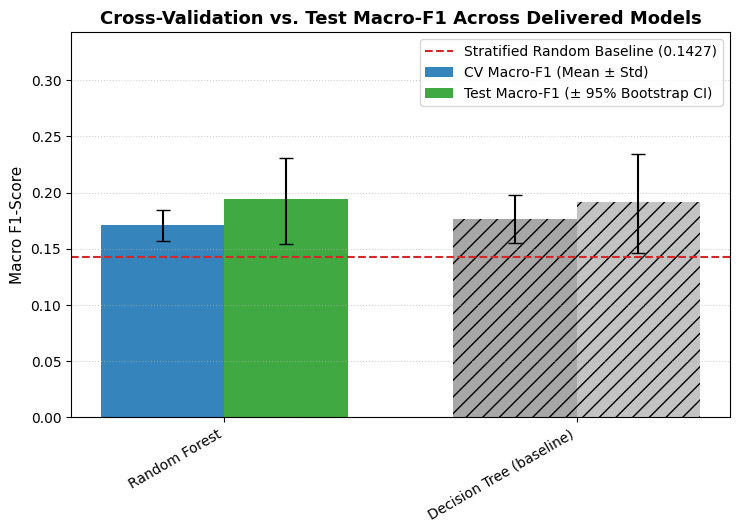

✔ Figure 7a saved to: results/phase2/comparison/comparison_macro_f1.png


In [7]:
# Figure 7a: Grouped Bar Chart of CV vs. Test Macro-F1
fig, ax = plt.subplots(figsize=(8.5, 5))

model_keys = list(primary_models.keys()) + list(baseline_models.keys())
model_labels = [
    passed_models[k]["data"]["meta"].get("model_label", k) + (" (baseline)" if EXPECTED_MODELS[k]["role"] == "baseline" else "")
    for k in model_keys
]
n_mod = len(model_keys)
x = np.arange(n_mod)
width = 0.35

cv_means = [passed_models[k]["data"]["cv"]["macro_f1"]["mean"] for k in model_keys]
cv_stds = [passed_models[k]["data"]["cv"]["macro_f1"]["std"] for k in model_keys]
test_scores = [passed_models[k]["data"]["test"]["macro_f1"] for k in model_keys]

test_err_low = [test_scores[i] - boot_cis[k][0] for i, k in enumerate(model_keys)]
test_err_high = [boot_cis[k][1] - test_scores[i] for i, k in enumerate(model_keys)]

role_colors_cv = ["#9e9e9e" if EXPECTED_MODELS[k]["role"] == "baseline" else "#1f77b4" for k in model_keys]
role_colors_test = ["#bdbdbd" if EXPECTED_MODELS[k]["role"] == "baseline" else "#2ca02c" for k in model_keys]
cv_bars = ax.bar(x - width/2, cv_means, width, yerr=cv_stds, capsize=5, label="CV Macro-F1 (Mean ± Std)", color=role_colors_cv, alpha=0.9)
test_bars = ax.bar(x + width/2, test_scores, width, yerr=[test_err_low, test_err_high], capsize=5, label="Test Macro-F1 (± 95% Bootstrap CI)", color=role_colors_test, alpha=0.9)
for idx, k in enumerate(model_keys):
    if EXPECTED_MODELS[k]["role"] == "baseline":
        cv_bars[idx].set_hatch("//")
        test_bars[idx].set_hatch("//")

strat_ref = ref_data["baselines"]["stratified_random"]["macro_f1_mean"]
ax.axhline(strat_ref, color="#d62728", linestyle="--", linewidth=1.5, label=f"Stratified Random Baseline ({strat_ref:.4f})")

ax.set_title("Cross-Validation vs. Test Macro-F1 Across Delivered Models", fontsize=13, fontweight="bold")
ax.set_ylabel("Macro F1-Score", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=30, ha="right", fontsize=10)
ax.set_ylim(0, max(max(cv_means) + max(cv_stds), max(test_scores) + 0.08) * 1.25)
ax.grid(True, linestyle=":", alpha=0.6, axis="y")
ax.legend(loc="upper right", frameon=True)

fig_path_a = COMPARISON_DIR / "comparison_macro_f1.png"
fig.savefig(fig_path_a, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Figure 7a saved to: {rel(fig_path_a)}")

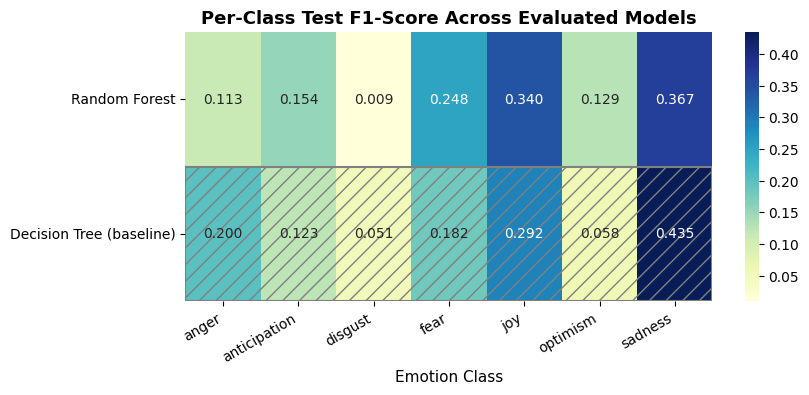

✔ Figure 7b saved to: results/phase2/comparison/comparison_per_class_f1.png


In [8]:
# Figure 7b: Per-Class F1-Score Heatmap
labels = ref_data["labels"]
heatmap_data = []
row_labels = []

for k in model_keys:
    d = passed_models[k]["data"]
    suffix = " (baseline)" if EXPECTED_MODELS[k]["role"] == "baseline" else ""
    row_labels.append(d["meta"].get("model_label", k) + suffix)
    heatmap_data.append([d["test"]["per_class"][lbl]["f1"] for lbl in labels])

fig, ax = plt.subplots(figsize=(8.5, max(3.5, len(model_keys) * 1.5)))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=labels,
    yticklabels=row_labels,
    cbar=True,
    ax=ax,
)
ax.set_title("Per-Class Test F1-Score Across Evaluated Models", fontsize=13, fontweight="bold")
ax.set_xlabel("Emotion Class", fontsize=11)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)
for row_idx, k in enumerate(model_keys):
    if EXPECTED_MODELS[k]["role"] == "baseline":
        ax.add_patch(plt.Rectangle((0, row_idx), len(labels), 1, fill=False, edgecolor="grey", hatch="//", linewidth=1.5))

fig_path_b = COMPARISON_DIR / "comparison_per_class_f1.png"
fig.savefig(fig_path_b, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Figure 7b saved to: {rel(fig_path_b)}")

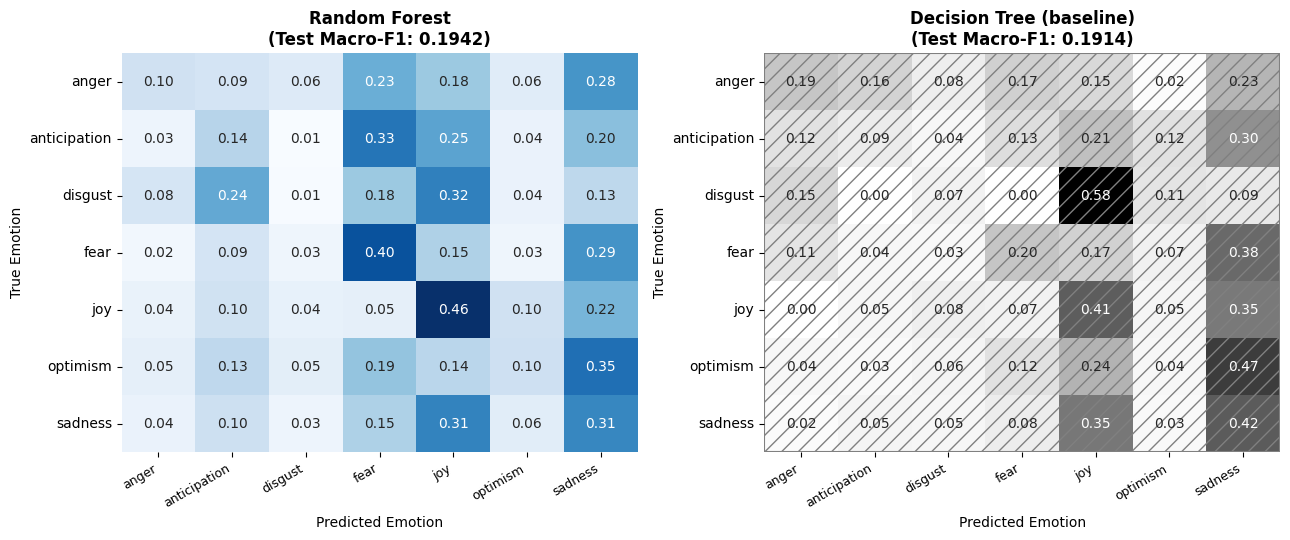

✔ Figure 7c saved to: results/phase2/comparison/comparison_confusion_matrices.png


In [9]:
# Figure 7c: Grid of Row-Normalized Test Confusion Matrices
n_mod = len(model_keys)
fig, ax = plt.subplots(1, n_mod, figsize=(6.5 * n_mod, 5.5), squeeze=False)

for i, k in enumerate(model_keys):
    panel_ax = ax[0, i]
    d = passed_models[k]["data"]
    is_baseline = EXPECTED_MODELS[k]["role"] == "baseline"
    lbl = d["meta"].get("model_label", k) + (" (baseline)" if is_baseline else "")
    cm_norm = confusion_matrix_normalized(d["test"]["confusion_matrix"])
    
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Greys" if is_baseline else "Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar=False,
        ax=panel_ax,
    )
    panel_ax.set_title(f"{lbl}\n(Test Macro-F1: {d['test']['macro_f1']:.4f})", fontsize=12, fontweight="bold")
    panel_ax.set_xlabel("Predicted Emotion", fontsize=10)
    panel_ax.set_ylabel("True Emotion", fontsize=10)
    panel_ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    if is_baseline:
        panel_ax.add_patch(plt.Rectangle((0, 0), len(labels), len(labels), fill=False, edgecolor="grey", hatch="//", linewidth=1.5))

plt.tight_layout()
fig_path_c = COMPARISON_DIR / "comparison_confusion_matrices.png"
fig.savefig(fig_path_c, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Figure 7c saved to: {rel(fig_path_c)}")

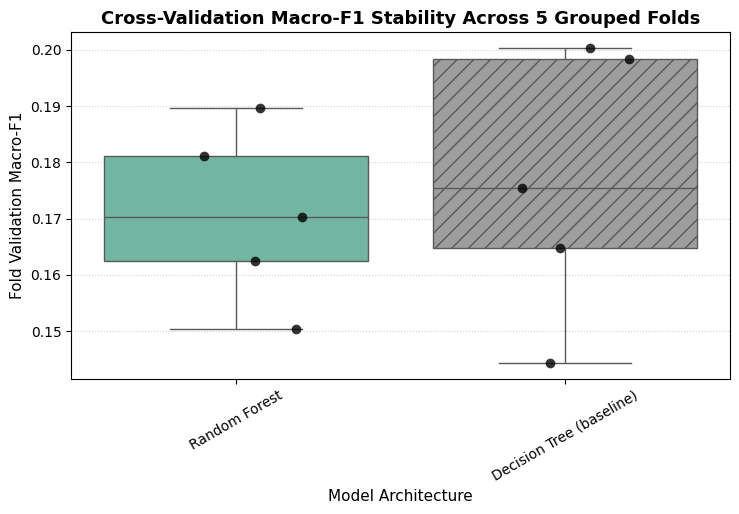

✔ Figure 7d saved to: results/phase2/comparison/comparison_cv_folds.png


In [10]:
# Figure 7d: Cross-Validation Fold Stability Box & Strip Plot
fold_records = []
for k in model_keys:
    d = passed_models[k]["data"]
    role = EXPECTED_MODELS[k]["role"]
    lbl = d["meta"].get("model_label", k) + (" (baseline)" if role == "baseline" else "")
    for fold_num, score in enumerate(d["cv"]["macro_f1"]["folds"], start=1):
        fold_records.append({
            "Model": lbl,
            "Role": role,
            "Fold": fold_num,
            "Macro-F1": score,
        })

df_folds = pd.DataFrame(fold_records)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
fold_palette = {label: ("#9e9e9e" if EXPECTED_MODELS[k]["role"] == "baseline" else "#66c2a5") for label, k in zip(model_labels, model_keys)}
sns.boxplot(
    x="Model",
    y="Macro-F1",
    hue="Model",
    data=df_folds,
    ax=ax,
    palette=fold_palette,
    legend=False,
)
sns.stripplot(
    x="Model",
    y="Macro-F1",
    data=df_folds,
    ax=ax,
    color="black",
    size=7,
    jitter=0.2,
    alpha=0.8,
)
for patch, k in zip(ax.patches, model_keys):
    if EXPECTED_MODELS[k]["role"] == "baseline":
        patch.set_hatch("//")

ax.set_title("Cross-Validation Macro-F1 Stability Across 5 Grouped Folds", fontsize=13, fontweight="bold")
ax.set_xlabel("Model Architecture", fontsize=11)
ax.set_ylabel("Fold Validation Macro-F1", fontsize=11)
ax.tick_params(axis="x", rotation=30)
ax.grid(True, linestyle=":", alpha=0.6, axis="y")

fig_path_d = COMPARISON_DIR / "comparison_cv_folds.png"
fig.savefig(fig_path_d, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Figure 7d saved to: {rel(fig_path_d)}")

### 8. Emotion Class Difficulty & Breakdown
Identify which emotions are systematically easiest and hardest to predict across all model architectures, and inspect the per-class precision, recall, and support of the top-performing model.

In [11]:
# Compute mean F1 per emotion class across primary models only.
class_mean_f1 = {}
for lbl in labels:
    class_mean_f1[lbl] = float(np.mean([primary_models[k]["data"]["test"]["per_class"][lbl]["f1"] for k in primary_models]))

sorted_classes = sorted(class_mean_f1.items(), key=lambda x: x[1])
hardest_class, hardest_score = sorted_classes[0]
easiest_class, easiest_score = sorted_classes[-1]

print("=== Emotion Class Difficulty Across Primary Models ===")
print(f"• Easiest Emotion (Highest Mean F1) : '{easiest_class}' (Mean F1: {easiest_score:.4f})")
print(f"• Hardest Emotion (Lowest Mean F1)  : '{hardest_class}' (Mean F1: {hardest_score:.4f})\n")

class_summary_df = pd.DataFrame([
    {"Emotion": lbl, "Mean Test F1 Across Models": f"{class_mean_f1[lbl]:.4f}"}
    for lbl in [sc[0] for sc in sorted_classes[::-1]]
])
print(class_summary_df.to_string(index=False))

# Best primary model per-class metrics table
best_lbl = best_d["meta"].get("model_label", best_key)

best_per_class = pd.DataFrame(best_d["test"]["per_class"]).T[["precision", "recall", "f1", "support"]]
best_per_class.columns = ["Precision", "Recall", "F1-Score", "Support"]
best_per_class["Support"] = best_per_class["Support"].astype(int)

print(f"\n=== Best Primary Model ({best_lbl}) Detailed Per-Class Breakdown ===")
print(best_per_class.round(4).to_string())

=== Emotion Class Difficulty Across Primary Models ===
• Easiest Emotion (Highest Mean F1) : 'sadness' (Mean F1: 0.3669)
• Hardest Emotion (Lowest Mean F1)  : 'disgust' (Mean F1: 0.0093)

     Emotion Mean Test F1 Across Models
     sadness                     0.3669
         joy                     0.3403
        fear                     0.2480
anticipation                     0.1537
    optimism                     0.1288
       anger                     0.1125
     disgust                     0.0093

=== Best Primary Model (Random Forest) Detailed Per-Class Breakdown ===
              Precision  Recall  F1-Score  Support
anger            0.1333  0.0973    0.1125      185
anticipation     0.1690  0.1409    0.1537      433
disgust          0.0093  0.0093    0.0093      107
fear             0.1803  0.3971    0.2480      277
joy              0.2716  0.4557    0.3403      553
optimism         0.1765  0.1014    0.1288      355
sadness          0.4583  0.3059    0.3669     1311


### 9. Fairness Caveats & Methodological Context
Synthesize preprocessing configurations, hyperparameter optimization budgets, and execution environments to contextualize performance differences.

In [12]:
caveat_records = []
for k in model_keys:
    d = passed_models[k]["data"]
    meta = d["meta"]
    tuning = meta["tuning"]
    cw = d.get("created_with", {})
    role = EXPECTED_MODELS[k]["role"]
    caveat_records.append({
        "Model": meta.get("model_label", k) + (" (baseline)" if role == "baseline" else ""),
        "Role": role,
        "Preprocessing Pipeline": meta.get("preprocessing", "-"),
        "Tuning Method": tuning.get("method", "-"),
        "Tuning Budget": f"{tuning.get('n_configs', '-')} configs x {tuning.get('n_folds', '-')} folds",
        "Elapsed Time (s)": f"{tuning.get('elapsed_seconds', 0.0):.1f}s",
        "Python": cw.get("python", "-"),
        "scikit-learn": cw.get("sklearn", "-"),
    })

caveat_df = pd.DataFrame(caveat_records)
print("=== Experimental Budget & Environment Context ===")
print(caveat_df.to_string(index=False))

=== Experimental Budget & Environment Context ===
                   Model     Role                                             Preprocessing Pipeline      Tuning Method        Tuning Budget Elapsed Time (s) Python scikit-learn
           Random Forest  primary TF-IDF (2500) + Genre Binarizer (20) + Word Count (1) + Rating (1) RandomizedSearchCV 15 configs x 5 folds           338.4s 3.14.3        1.9.0
Decision Tree (baseline) baseline TF-IDF (2500) + Genre Binarizer (20) + Word Count (1) + Rating (1)       GridSearchCV 30 configs x 5 folds           627.0s 3.14.3        1.9.0


#### Methodological Considerations for Group Synthesis:
1. **Hyperparameter Tuning Budgets:** Competing models were evaluated under varying computational search budgets (e.g., exhaustive grid search vs. randomized sampling) reflecting architectural execution costs.
2. **Cluster Grouping & Single Split:** The held-out test set comprises 3,221 reviews across exactly 261 movies. While cluster-level grouping prevents information leakage, all comparisons reflect this specific held-out test split.
3. **Library Version Sensitivity:** Individual decision tree splits and numerical ties in greedy impurity reduction can exhibit slight variation across scikit-learn versions, even with fixed random seeds.

### 10. Summary Serialization
Export structured summary metadata to `results/phase2/comparison/comparison_summary.json` for automated consumption and reporting.

In [13]:
summary_payload = {
    "reference_model": ref_key,
    "models_evaluated_count": len(delivered_data),
    "models_passed_count": len(passed_models),
    "models_included": list(passed_models.keys()),
    "models_excluded": excluded_models,
    "best_model": {
        "model_key": best_key,
        "model_label": best_lbl,
        "test_macro_f1": float(best_d["test"]["macro_f1"]),
        "test_accuracy": float(best_d["test"]["accuracy"]),
    },
    "statistically_tied_with_best": tied_primary_models,
    "roles": {key: spec["role"] for key, spec in EXPECTED_MODELS.items()},
    "primary_models_delivered": int(primary_models_delivered),
    "primary_models_expected": int(PRIMARY_MODELS_EXPECTED),
    "best_primary_model": {
        "model_key": best_key,
        "model_label": best_lbl,
        "test_macro_f1": float(best_d["test"]["macro_f1"]),
        "test_accuracy": float(best_d["test"]["accuracy"]),
    },
    "tied_primary_models": tied_primary_models,
    "baseline_models": list(baseline_models.keys()),
    "rankings": {
        "cv_macro_f1_ranking": [passed_models[k]["data"]["meta"].get("model_label", k) for k in cv_rank_order],
        "test_macro_f1_ranking": [passed_models[k]["data"]["meta"].get("model_label", k) for k in test_rank_order],
    },
    "generated_artifacts": {
        "comparison_table_csv": rel(csv_out),
        "comparison_table_md": rel(md_out),
        "figure_macro_f1": rel(fig_path_a),
        "figure_per_class_f1": rel(fig_path_b),
        "figure_confusion_matrices": rel(fig_path_c),
        "figure_cv_folds": rel(fig_path_d),
    },
}

summary_json_path = COMPARISON_DIR / "comparison_summary.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print("=== Comparison Summary Exported ===")
print(f"• Summary JSON: {rel(summary_json_path)}")
print(json.dumps(summary_payload, indent=2))

=== Comparison Summary Exported ===
• Summary JSON: results/phase2/comparison/comparison_summary.json
{
  "reference_model": "decision_tree",
  "models_evaluated_count": 2,
  "models_passed_count": 2,
  "models_included": [
    "decision_tree",
    "random_forest"
  ],
  "models_excluded": {},
  "best_model": {
    "model_key": "random_forest",
    "model_label": "Random Forest",
    "test_macro_f1": 0.19421056492629904,
    "test_accuracy": 0.2728966159577771
  },
  "statistically_tied_with_best": [],
  "roles": {
    "naive_bayes": "primary",
    "logistic_regression": "primary",
    "linear_svc": "primary",
    "random_forest": "primary",
    "hist_gradient_boosting": "primary",
    "mlp": "primary",
    "decision_tree": "baseline"
  },
  "primary_models_delivered": 1,
  "primary_models_expected": 6,
  "best_primary_model": {
    "model_key": "random_forest",
    "model_label": "Random Forest",
    "test_macro_f1": 0.19421056492629904,
    "test_accuracy": 0.2728966159577771
  },
  